In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, recall_score, confusion_matrix, precision_score
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as IMBpipeline
import os
import pickle

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
os.makedirs(os.path.join(project_root, 'models'), exist_ok=True)
os.makedirs(os.path.join(project_root, "images"), exist_ok=True)

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

In [3]:
categorical_cols = ["ever_married", "work_type", "Residence_type", "smoking_status", "gender"]
numerical_cols = ["age", "bmi", "avg_glucose_level"]
binary_cols = ["hypertension", "heart_disease"]

In [4]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="if_binary", handle_unknown="ignore", categories=[
            ['No', 'Yes'],                                      # ever_married
            ['Govt_job', 'Never_worked', 'Private',
            'Self-employed', 'children'],                      # work_type
            ['Rural', 'Urban'],                                 # Residence_type
            ['formerly smoked', 'never smoked', 'smokes'],     # smoking_status
            ['Female', 'Male', 'Other'] ]))
])

In [5]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [6]:
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

In [7]:
preprocessing = ColumnTransformer([
    ("categorical", categorical_pipeline, categorical_cols),
    ("numerical", numerical_pipeline, numerical_cols),
    ("binary", binary_pipeline, binary_cols)
])

In [8]:
full_pipeline = IMBpipeline([
    ("preprocessor", preprocessing),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=10000))
])

In [9]:
params_grid = [
    {
        "model__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        "model__l1_ratio": [0.1, 0.5, 1],
        "model__solver": ["saga"],
        "model__class_weight": ["balanced", None]
    }
]

In [10]:
random_search = RandomizedSearchCV(full_pipeline, param_distributions=params_grid, cv=3, scoring="roc_auc", verbose=1, n_iter=21, n_jobs=-1, random_state=42)

In [11]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 21 candidates, totalling 63 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...iter=10000))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model__C': [0.001, 0.01, ...], 'model__class_weight': ['balanced', None], 'model__l1_ratio': [0.1, 0.5, ...], 'model__solver': ['saga']}]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",21
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

In [12]:
random_search.best_params_

{'model__solver': 'saga',
 'model__l1_ratio': 1,
 'model__class_weight': 'balanced',
 'model__C': 0.01}

In [13]:
y_pred = random_search.predict(X_test)

In [14]:
y_pred_proba = random_search.predict_proba(X_test)[:, 1]

In [15]:
roc_auc = roc_auc_score(y_test, y_pred_proba)

In [16]:
roc_auc

0.8396707818930041

In [17]:
confusion_matrix(y_test, y_pred)

array([[722, 250],
       [ 10,  40]])

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

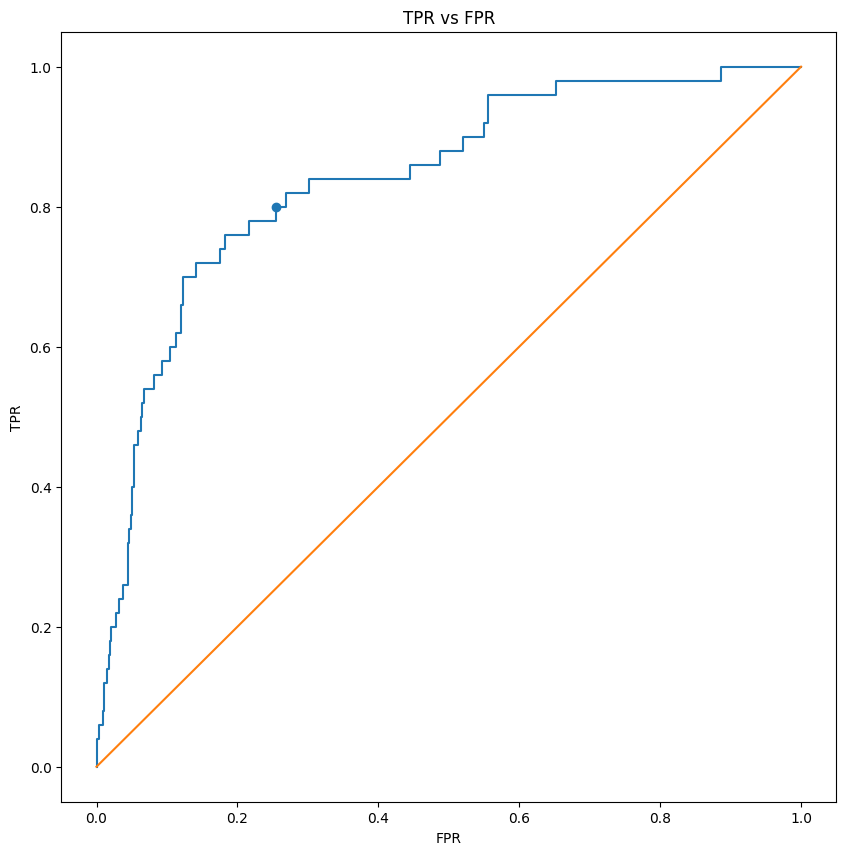

In [19]:
plt.figure(figsize=(10, 10))
plt.title("TPR vs FPR")
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
default_idx = np.argmin(np.abs(thresholds - 0.5))
plt.scatter(fpr[default_idx], tpr[default_idx])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.savefig("../images/tpr_vs_fpr.png")
plt.show()

In [20]:
best_threshold = 0
min_recall = 0.94
best_recall = 0
min_precision = 0
for threshold in thresholds:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    recall = recall_score(y_test, y_pred_t, zero_division=0)
    precision = precision_score(y_test, y_pred_t, zero_division=0)
    if recall >= min_recall:
        if precision > min_precision:
            min_precision = precision
            best_threshold = threshold
            best_recall = recall
print(f"Best threshold: {best_threshold} Best recall: {best_recall}")

Best threshold: 0.1643121938190271 Best recall: 0.96


In [21]:
y_pred_new = (y_pred_proba >= best_threshold).astype(int)
confusion_matrix(y_test, y_pred_new)

array([[432, 540],
       [  2,  48]])

In [22]:
with open("../models/model.pkl", "wb") as fp:
    pickle.dump(random_search.best_estimator_, fp)
with open("../models/threshold.pkl", "wb") as fp:
    pickle.dump(best_threshold, fp)